# STEP 7 — Robustness: ablation + confidence interval (CI) + significance

Closes the "are the results real or chance?" question. Model: RAW LightGBM (Step 2
best_params). 5 seeds (config.seeds = [42, 7, 123, 2024, 99]); all repeated results are
mean ± std + 95% CI. Sets are separate; no merging. The heavy logic lives in `src/robustness.py`.

- **Part 1 — Profit-chain ablation** (telco + cell2cell): remove/break each component of the thesis,
  measure the effect in MONEY (profit/ROI). Reference: c=5% avg-CLV, γ=0.30, horizon 24 months.
- **Part 2 — Repeated runs + CI** (5 sets): are the main metrics stable against the seed?
- **Part 3 — Significance**: are model/strategy differences real or noise (Wilcoxon).

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml not found")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

warnings.filterwarnings("ignore")
from src import config as cfg
from src import robustness as rb
from src import strings as S

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)

CIKTI = []


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))


veriler = {k: pd.read_csv(cfg.PROCESSED / f"{k}_clean.csv") for k in cfg.DATASETS}
yaz(f"Seeds: {rb.SEEDS} | reference c=%{int(rb.C_ORAN*100)} avg-CLV, γ={rb.GAMMA}")

Seeds: [42, 7, 123, 2024, 99] | reference c=%5 avg-CLV, γ=0.3


## Part 1 — Profit-chain ablation (telco + cell2cell)
K0 full system (raw + profit-threshold); K1 −profit-threshold (0.5); K2 −calibration (class-weight);
K3 −strong model (LogReg); K4 +imbalance (SMOTE). Each with 5 seeds.

In [2]:
yaz(S.MSG["bolum"].format(ad="PART 1 — PROFIT-CHAIN ABLATION"))
tum_abl = {}
for s in rb.ABLATION_SETLERI:
    t = time.time()
    tum_abl[s] = rb.ablation_set(s, veriler[s])
    for kosul, v in tum_abl[s].items():
        yaz(S.MSG7["ablation"].format(set=s, kosul=kosul, kar=v["kar"], roi=v["roi"],
            ece=v["ece"], esik=v["esik"], dkar=v["dkar"], yuzde=v["dkar_yuzde"]))
    yaz(f"  ({time.time()-t:.0f}s)")
abl_df = rb.tablo_ablation(tum_abl)
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "ablation_profit.csv"))

===== PART 1 — PROFIT-CHAIN ABLATION =====


telco / K0: profit=543647 ROI=1.32 ECE=0.009 t*=0.05 | Δvs K0=+0 (+0.0%)
telco / K1: profit=-1075056 ROI=-9.62 ECE=0.009 t*=0.50 | Δvs K0=-1618703 (-297.7%)
telco / K2: profit=541433 ROI=1.36 ECE=0.131 t*=0.11 | Δvs K0=-2215 (-0.4%)
telco / K3: profit=525916 ROI=1.25 ECE=0.013 t*=0.04 | Δvs K0=-17732 (-3.3%)
telco / K4: profit=542918 ROI=1.34 ECE=0.083 t*=0.06 | Δvs K0=-729 (-0.1%)
  (61s)


cell2cell / K0: profit=2537959 ROI=0.71 ECE=0.005 t*=0.06 | Δvs K0=+0 (+0.0%)
cell2cell / K1: profit=-17393887 ROI=-71.71 ECE=0.005 t*=0.50 | Δvs K0=-19931847 (-785.3%)
cell2cell / K2: profit=2538276 ROI=0.71 ECE=0.169 t*=0.11 | Δvs K0=+316 (+0.0%)
cell2cell / K3: profit=2536017 ROI=0.70 ECE=0.008 t*=0.01 | Δvs K0=-1942 (-0.1%)
cell2cell / K4: profit=2538286 ROI=0.71 ECE=0.032 t*=0.07 | Δvs K0=+327 (+0.0%)
  (446s)


ecommerce / K0: profit=254561 ROI=1.39 ECE=0.038 t*=0.01 | Δvs K0=+0 (+0.0%)
ecommerce / K1: profit=-48988 ROI=-0.38 ECE=0.038 t*=0.50 | Δvs K0=-303548 (-119.2%)
ecommerce / K2: profit=278776 ROI=1.44 ECE=0.040 t*=0.01 | Δvs K0=+24216 (+9.5%)
ecommerce / K3: profit=74107 ROI=0.16 ECE=0.015 t*=0.05 | Δvs K0=-180453 (-70.9%)
ecommerce / K4: profit=260215 ROI=1.37 ECE=0.045 t*=0.01 | Δvs K0=+5655 (+2.2%)
  (254s)


iranian / K0: profit=652 ROI=0.04 ECE=0.013 t*=0.06 | Δvs K0=+0 (+0.0%)
iranian / K1: profit=-3394 ROI=-0.31 ECE=0.013 t*=0.50 | Δvs K0=-4046 (-620.3%)
iranian / K2: profit=621 ROI=0.04 ECE=0.016 t*=0.11 | Δvs K0=-32 (-4.8%)
iranian / K3: profit=-19126 ROI=-0.97 ECE=0.020 t*=0.18 | Δvs K0=-19778 (-3032.4%)
iranian / K4: profit=1073 ROI=0.07 ECE=0.020 t*=0.15 | Δvs K0=+421 (+64.5%)
  (1384s)


bank / K0: profit=968545 ROI=0.87 ECE=0.011 t*=0.05 | Δvs K0=+0 (+0.0%)
bank / K1: profit=-3019230 ROI=-15.38 ECE=0.011 t*=0.50 | Δvs K0=-3987775 (-411.7%)
bank / K2: profit=955527 ROI=0.86 ECE=0.151 t*=0.13 | Δvs K0=-13018 (-1.3%)
bank / K3: profit=771124 ROI=0.58 ECE=0.008 t*=0.05 | Δvs K0=-197421 (-20.4%)
bank / K4: profit=923422 ROI=0.80 ECE=0.130 t*=0.10 | Δvs K0=-45123 (-4.7%)
  (61s)
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/tables/ablation_profit.csv


## Part 2 — Repeated runs + 95% CI (5 sets)

In [3]:
yaz(S.MSG["bolum"].format(ad="PART 2 — REPEATED RUNS + CI"))
tum_ci = {}
for s in cfg.DATASETS:
    t = time.time()
    tum_ci[s] = rb.robustness_set(s, veriler[s])
    for metrik, (m, std, lo, hi) in tum_ci[s].items():
        yaz(S.MSG7["ci"].format(set=s, metrik=metrik, ort=m, std=std, lo=lo, hi=hi))
    yaz(f"  ({time.time()-t:.0f}s)")
ci_df = rb.tablo_ci(tum_ci)
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "robustness_ci.csv"))

===== PART 2 — REPEATED RUNS + CI =====


telco PR-AUC: 0.6639 ± 0.0014  [95% CI 0.6621, 0.6657]
telco ROC-AUC: 0.8473 ± 0.0004  [95% CI 0.8467, 0.8478]
telco recall: 0.9832 ± 0.0027  [95% CI 0.9799, 0.9865]
telco precision: 0.3462 ± 0.0077  [95% CI 0.3367, 0.3557]
telco F1: 0.5120 ± 0.0081  [95% CI 0.5020, 0.5221]
telco EMP: 0.0497 ± 0.0005  [95% CI 0.0491, 0.0503]
  (1s)


cell2cell PR-AUC: 0.4659 ± 0.0010  [95% CI 0.4646, 0.4671]
cell2cell ROC-AUC: 0.6853 ± 0.0009  [95% CI 0.6842, 0.6865]
cell2cell recall: 0.9997 ± 0.0005  [95% CI 0.9991, 1.0003]
cell2cell precision: 0.2887 ± 0.0007  [95% CI 0.2878, 0.2896]
cell2cell F1: 0.4480 ± 0.0008  [95% CI 0.4471, 0.4490]
cell2cell EMP: 0.0352 ± 0.0000  [95% CI 0.0352, 0.0353]
  (7s)


ecommerce PR-AUC: 0.9040 ± 0.0072  [95% CI 0.8950, 0.9130]
ecommerce ROC-AUC: 0.9656 ± 0.0044  [95% CI 0.9602, 0.9711]
ecommerce recall: 0.9080 ± 0.0076  [95% CI 0.8986, 0.9174]
ecommerce precision: 0.7101 ± 0.0113  [95% CI 0.6961, 0.7241]
ecommerce F1: 0.7969 ± 0.0088  [95% CI 0.7860, 0.8078]
ecommerce EMP: 0.0152 ± 0.0015  [95% CI 0.0134, 0.0171]
  (0s)


iranian PR-AUC: 0.9549 ± 0.0027  [95% CI 0.9515, 0.9582]
iranian ROC-AUC: 0.9889 ± 0.0012  [95% CI 0.9874, 0.9904]
iranian recall: 0.9657 ± 0.0065  [95% CI 0.9575, 0.9738]
iranian precision: 0.7630 ± 0.0303  [95% CI 0.7254, 0.8007]
iranian F1: 0.8521 ± 0.0166  [95% CI 0.8315, 0.8727]
iranian EMP: 0.0004 ± 0.0003  [95% CI 0.0001, 0.0008]
  (0s)


bank PR-AUC: 0.7031 ± 0.0019  [95% CI 0.7007, 0.7054]
bank ROC-AUC: 0.8659 ± 0.0007  [95% CI 0.8651, 0.8668]
bank recall: 0.9680 ± 0.0049  [95% CI 0.9619, 0.9741]
bank precision: 0.2711 ± 0.0105  [95% CI 0.2580, 0.2842]
bank F1: 0.4234 ± 0.0122  [95% CI 0.4083, 0.4386]
bank EMP: 0.0317 ± 0.0005  [95% CI 0.0311, 0.0323]
  (1s)
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/tables/robustness_ci.csv


## Part 3 — Significance (Wilcoxon, paired scores)

In [4]:
yaz(S.MSG["bolum"].format(ad="PART 3 — SIGNIFICANCE"))
sig_df, pmat, modeller, n = rb.anlamlilik(veriler)
yaz(S.MSG7["yontem"].format(n=n))
yaz(sig_df.to_string(index=False))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "significance_tests.csv"))

===== PART 3 — SIGNIFICANCE =====


Significance method: Wilcoxon signed-rank over paired scores (dataset×seed OOF PR-AUC, n=25).
                                     Comparison     Test  Statistic  p-value               Result
                        lgbm vs logreg (PR-AUC) Wilcoxon        0.0  0.00000 significant (p<0.05)
                       lgbm vs xgboost (PR-AUC) Wilcoxon       95.0  0.07098       noise (p≥0.05)
                     logreg vs xgboost (PR-AUC) Wilcoxon        0.0  0.00000 significant (p<0.05)
Profit threshold (K0) vs accuracy (K1) — profit Wilcoxon        0.0  0.00000 significant (p<0.05)
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/tables/significance_tests.csv


## Figures

===== FIGURES =====


Saved: /Users/emrahfidan/Desktop/makale-2/outputs/figures/_robust/ablation_profit_waterfall.png
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/figures/_robust/robustness_ci_forest.png
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/figures/_robust/significance_heatmap.png


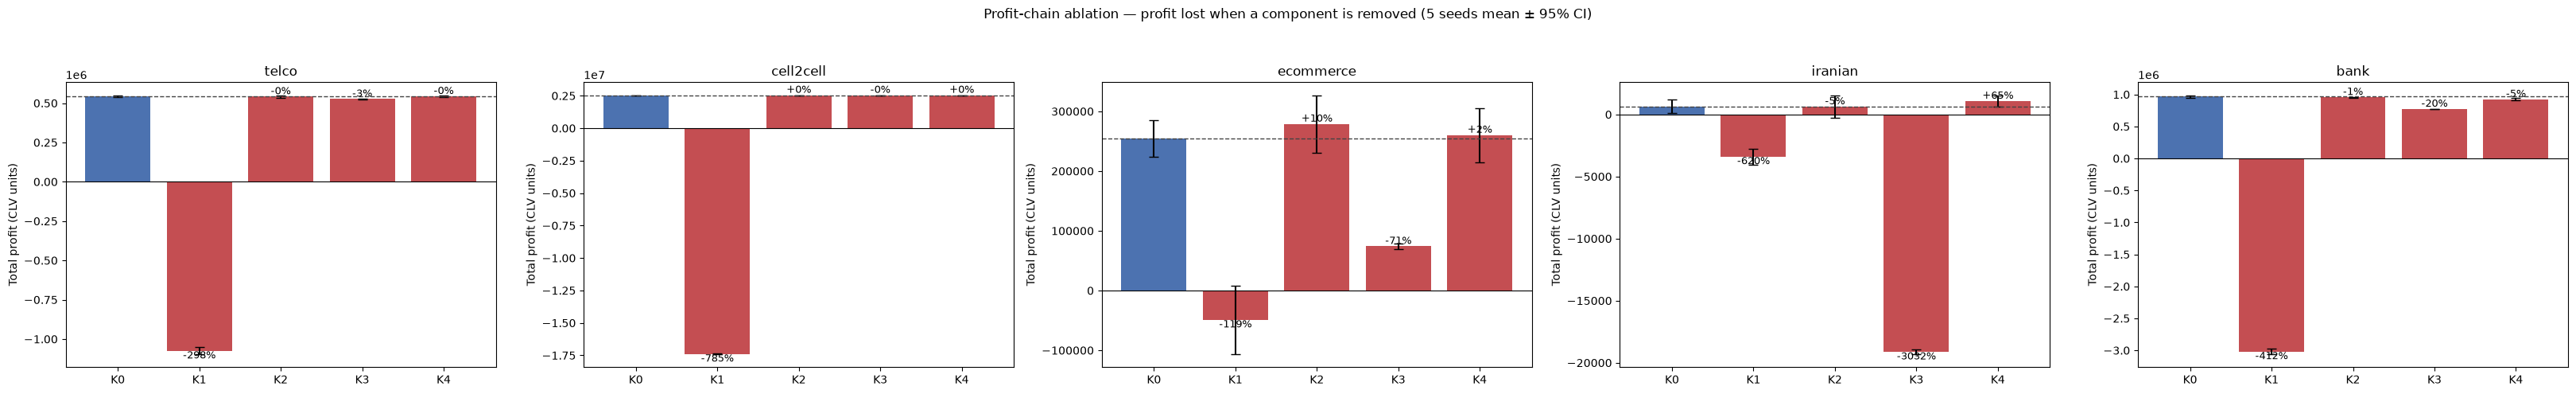

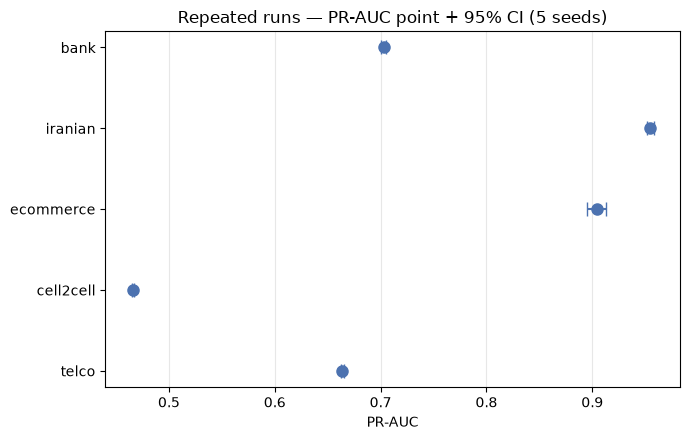

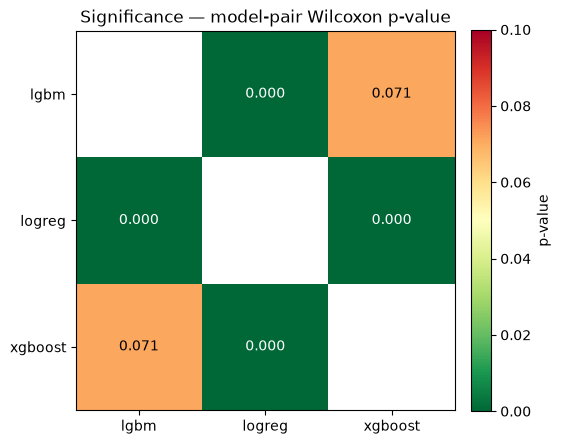

In [5]:
yaz(S.MSG["bolum"].format(ad="FIGURES"))
y1 = rb.figur_ablation(tum_abl)
y2 = rb.figur_ci(tum_ci)
y3 = rb.figur_significance(pmat, modeller)
for y in (y1, y2, y3):
    yaz(S.MSG["kayit"].format(yol=y))

## Summary — decision left to the user

In [6]:
yaz(S.MSG["bolum"].format(ad="SUMMARY — ROBUSTNESS"))
yaz("ABLATION (profit loss % vs K0):")
for s in rb.ABLATION_SETLERI:
    d = tum_abl[s]
    sirali = sorted([(k, d[k]["dkar_yuzde"]) for k in d if k != "K0"], key=lambda x: x[1])
    yaz(f"  {s}: " + " | ".join(f"{k}={dy:+.0f}%" for k, dy in sirali))
yaz("\nCI width (PR-AUC, max std):")
maxstd = max(tum_ci[s]["PR-AUC"][1] for s in cfg.DATASETS)
yaz(f"  widest PR-AUC std = {maxstd:.4f} -> {'very tight, results stable' if maxstd < 0.02 else 'caution'}")
yaz("\nSIGNIFICANCE:")
for _, r in sig_df.iterrows():
    yaz(f"  {r[S.KOLON7['kiyas']]}: p={r[S.KOLON7['p']]} -> {r[S.KOLON7['sonuc']]}")
yaz("")
yaz(S.MSG7["bitti"])

_log = cfg.LOGS / "adim7_ozet.log"
_log.write_text("\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log))

===== SUMMARY — ROBUSTNESS =====
ABLATION (profit loss % vs K0):
  telco: K1=-298% | K3=-3% | K2=-0% | K4=-0%
  cell2cell: K1=-785% | K3=-0% | K2=+0% | K4=+0%
  ecommerce: K1=-119% | K3=-71% | K4=+2% | K2=+10%
  iranian: K3=-3032% | K1=-620% | K2=-5% | K4=+65%
  bank: K1=-412% | K3=-20% | K4=-5% | K2=-1%

CI width (PR-AUC, max std):
  widest PR-AUC std = 0.0072 -> very tight, results stable

SIGNIFICANCE:
  lgbm vs logreg (PR-AUC): p=0.0 -> significant (p<0.05)
  lgbm vs xgboost (PR-AUC): p=0.07098 -> noise (p≥0.05)
  logreg vs xgboost (PR-AUC): p=0.0 -> significant (p<0.05)
  Profit threshold (K0) vs accuracy (K1) — profit: p=0.0 -> significant (p<0.05)

STEP 7 (robustness) complete. Experimental phase done; interpretation left to the user, write-up next.
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/logs/adim7_ozet.log
